# 02 - Sizing and MTOW Convergence

Aircraft sizing requires resolving a **circular dependency**: structural and battery masses depend on MTOW, but MTOW is the sum of those masses plus payload. `evtolpy` uses a **fixed-point iteration** to resolve this:

$$MTOW_{n+1} = f(MTOW_n) = m_{struct}(MTOW_n) + m_{prop}(MTOW_n) + m_{batt}(MTOW_n) + m_{payload} + m_{fixed}$$

The iteration converges when $|MTOW_{n+1} - MTOW_n| < \epsilon$ (default: 0.001 kg). This notebook applies the MTOW iteration to the Archer Midnight and examines the resulting mass breakdown.

The coupling paths that create this circular dependency:
```
MTOW → wing/tail/fuselage mass (structural sizing)
MTOW → hover power → energy → battery mass (power chain)
MTOW → stall speed → wing area → drag → cruise power → energy → battery mass
```

In [11]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

ac = Aircraft('../Archer_Midnight.json')

## MTOW Iteration

The `_iterate_mtow()` method starts from the initial MTOW guess in the JSON file and iterates until the mass change between iterations falls below the convergence tolerance (0.001 kg by default).

each iteration:
1. Computes structural masses from current MTOW (parametric models based on Raymer/NDARC)
2. Computes power requirements for each mission segment
3. Integrates energy across the mission
4. Sizes the battery from total energy and usable specific energy
5. Sums all components to get a new MTOW estimate

In [12]:
final_mtow, history = ac._iterate_mtow()

print(f"Initial MTOW guess:  {history[0]['mtow_guess_kg']:.2f} kg")
print(f"Converged MTOW:      {final_mtow:.2f} kg")
print(f"Iterations:          {len(history)}")
print(f"Final delta:         {history[-1]['delta_kg']:.6f} kg")

Initial MTOW guess:  3175.00 kg
Converged MTOW:      3193.36 kg
Iterations:          23
Final delta:         0.000990 kg


## Iteration History

In [13]:
print(f"{'Iter':>4s} {'Guess (kg)':>12s} {'New (kg)':>12s} {'Delta (kg)':>12s} {'Empty (kg)':>12s} {'Batt (kg)':>10s}")
print("-" * 65)
for row in history:
    print(f"{row['iteration']:>4d} {row['mtow_guess_kg']:>12.2f} {row['new_mtow_kg']:>12.2f} "
          f"{row['delta_kg']:>12.4f} {row['empty_mass_kg']:>12.2f} {row['battery_mass_kg']:>10.2f}")

Iter   Guess (kg)     New (kg)   Delta (kg)   Empty (kg)  Batt (kg)
-----------------------------------------------------------------
   0      3175.00      3181.02       6.0187      1758.99     969.03
   1      3181.02      3185.06       4.0426      1761.21     970.85
   2      3185.06      3187.78       2.7173      1762.71     972.07
   3      3187.78      3189.61       1.8274      1763.71     972.89
   4      3189.61      3190.84       1.2294      1764.39     973.45
   5      3190.84      3191.66       0.8272      1764.84     973.82
   6      3191.66      3192.22       0.5567      1765.15     974.07
   7      3192.22      3192.59       0.3747      1765.36     974.24
   8      3192.59      3192.85       0.2522      1765.49     974.35
   9      3192.85      3193.02       0.1698      1765.59     974.43
  10      3193.02      3193.13       0.1143      1765.65     974.48
  11      3193.13      3193.21       0.0769      1765.69     974.51
  12      3193.21      3193.26       0.0518      1

## Convergence Visualization

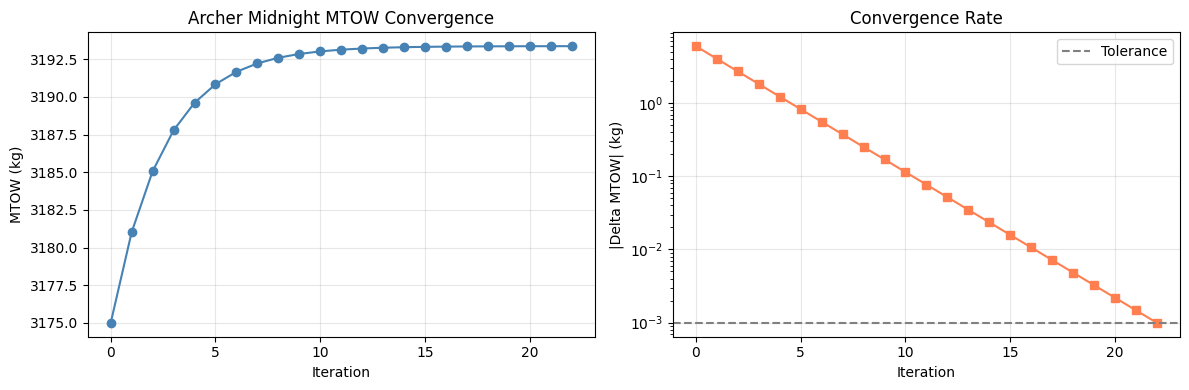

In [14]:
import matplotlib.pyplot as plt

iters = [row['iteration'] for row in history]
mtow_guesses = [row['mtow_guess_kg'] for row in history]
deltas = [abs(row['delta_kg']) for row in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, mtow_guesses, 'o-', color='steelblue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MTOW (kg)')
ax1.set_title('Archer Midnight MTOW Convergence')
ax1.grid(True, alpha=0.3)

ax2.semilogy(iters, deltas, 's-', color='coral')
ax2.axhline(y=0.001, color='gray', linestyle='--', label='Tolerance')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('|Delta MTOW| (kg)')
ax2.set_title('Convergence Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mass Breakdown

After convergence, we can examine how the Archer Midnight's mass is distributed across structural, propulsion, subsystem, and energy storage components.

The MTOW equation after convergence:

$$MTOW = m_{structural} + m_{propulsion} + m_{subsystems} + m_{battery} + m_{payload}$$


In [15]:
structural = {
    'Wing':               ac.wing_mass_kg,
    'Horizontal Tail':    ac.horiz_tail_mass_kg,
    'Vertical Tail':      ac.vert_tail_mass_kg,
    'Fuselage':           ac.fuselage_mass_kg,
    'Boom':               ac.boom_mass_kg,
    'Landing Gear':       ac.landing_gear_mass_kg,
}

propulsion = {
    'EPU (all rotors)':   ac.epu_mass_kg,
    'Lift Rotor + Hub':   ac.lift_rotor_hub_mass_kg,
    'Tilt Rotor':         ac.tilt_rotor_mass_kg,
}

subsystems = {
    'Actuators':          ac.actuator_mass_kg,
    'Furnishings':        ac.furnishings_mass_kg,
    'Env. Control':       ac.environmental_control_system_mass_kg,
    'Avionics':           ac.avionics_mass_kg,
    'Hi-Volt Power':      ac.hivolt_power_dist_mass_kg,
    'Lo-Volt Power':      ac.lovolt_power_coms_mass_kg,
}

print(f"{'Component':<22s} {'Mass (kg)':>10s} {'Fraction':>10s}")
print("=" * 44)

print("-- Structural --")
for name, mass in structural.items():
    print(f"  {name:<20s} {mass:>10.2f} {mass/ac.max_takeoff_mass_kg:>9.1%}")

print("-- Propulsion --")
for name, mass in propulsion.items():
    print(f"  {name:<20s} {mass:>10.2f} {mass/ac.max_takeoff_mass_kg:>9.1%}")

print("-- Subsystems --")
for name, mass in subsystems.items():
    print(f"  {name:<20s} {mass:>10.2f} {mass/ac.max_takeoff_mass_kg:>9.1%}")

print("=" * 44)
print(f"  {'Empty Mass':<20s} {ac.empty_mass_kg:>10.2f} {ac.empty_mass_kg/ac.max_takeoff_mass_kg:>9.1%}")
print(f"  {'Battery':<20s} {ac.battery_mass_kg:>10.2f} {ac.battery_mass_kg/ac.max_takeoff_mass_kg:>9.1%}")
print(f"  {'Payload':<20s} {ac.payload_kg:>10.2f} {ac.payload_kg/ac.max_takeoff_mass_kg:>9.1%}")
print("=" * 44)
print(f"  {'MTOW':<20s} {ac.max_takeoff_mass_kg:>10.2f}")

Component               Mass (kg)   Fraction
-- Structural --
  Wing                     319.35     10.0%
  Horizontal Tail           23.85      0.7%
  Vertical Tail             15.98      0.5%
  Fuselage                 171.73      5.4%
  Boom                     138.09      4.3%
  Landing Gear             127.78      4.0%
-- Propulsion --
  EPU (all rotors)         320.93     10.1%
  Lift Rotor + Hub          51.09      1.6%
  Tilt Rotor                55.90      1.8%
-- Subsystems --
  Actuators                150.00      4.7%
  Furnishings               67.00      2.1%
  Env. Control              40.00      1.3%
  Avionics                  60.00      1.9%
  Hi-Volt Power             80.00      2.5%
  Lo-Volt Power             60.00      1.9%
  Empty Mass              1765.78     55.3%
  Battery                  974.59     30.5%
  Payload                  453.00     14.2%
  MTOW                    3193.36


## Mass Breakdown Visualization

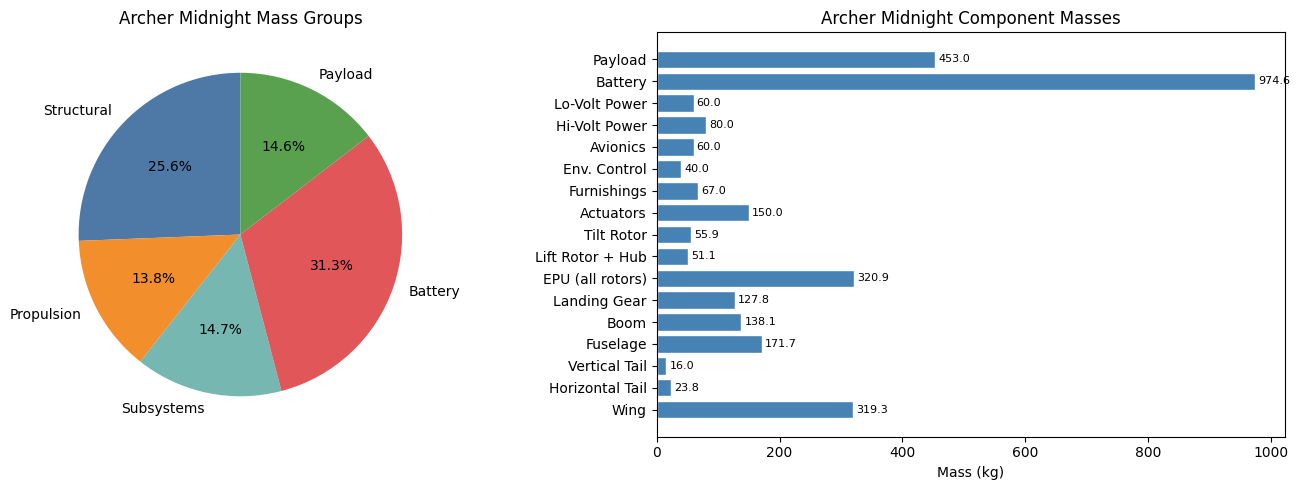

In [16]:
# Pie chart of major mass groups
groups = {
    'Structural': sum(structural.values()),
    'Propulsion': sum(propulsion.values()),
    'Subsystems': sum(subsystems.values()),
    'Battery': ac.battery_mass_kg,
    'Payload': ac.payload_kg,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#4e79a7', '#f28e2b', '#76b7b2', '#e15759', '#59a14f']
wedges, texts, autotexts = ax1.pie(
    groups.values(), labels=groups.keys(), autopct='%1.1f%%',
    colors=colors, startangle=90
)
ax1.set_title('Archer Midnight Mass Groups')

# Bar chart of individual components
all_components = {}
all_components.update(structural)
all_components.update(propulsion)
all_components.update(subsystems)
all_components['Battery'] = ac.battery_mass_kg
all_components['Payload'] = ac.payload_kg

names = list(all_components.keys())
masses = list(all_components.values())

bars = ax2.barh(names, masses, color='steelblue', edgecolor='white')
ax2.set_xlabel('Mass (kg)')
ax2.set_title('Archer Midnight Component Masses')
for bar, mass in zip(bars, masses):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{mass:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Energy Requirements

The converged sizing also determines the total mission energy, which drives battery mass. The 3-step power chain applies to each segment:

$$\text{Forces} \xrightarrow{\div \eta_{rotor}} P_{shaft} \xrightarrow{\div \eta_{epu}} P_{elec} \xrightarrow{\times t} E_{segment}$$


In [17]:
primary_segments = [
    ('Depart Taxi',         ac.depart_taxi_energy_kw_hr),
    ('Hover Climb',         ac.hover_climb_energy_kw_hr),
    ('Transition Climb',    ac.trans_climb_energy_kw_hr),
    ('Depart Procedures',   ac.depart_proc_energy_kw_hr),
    ('Accelerate Climb',    ac.accel_climb_energy_kw_hr),
    ('Cruise',              ac.cruise_energy_kw_hr),
    ('Decelerate Descend',  ac.decel_descend_energy_kw_hr),
    ('Arrive Procedures',   ac.arrive_proc_energy_kw_hr),
    ('Transition Descend',  ac.trans_descend_energy_kw_hr),
    ('Hover Descend',       ac.hover_descend_energy_kw_hr),
    ('Arrive Taxi',         ac.arrive_taxi_energy_kw_hr),
]

reserve_segments = [
    ('Rsv Hover Climb',     ac.reserve_hover_climb_energy_kw_hr),
    ('Rsv Trans. Climb',    ac.reserve_trans_climb_energy_kw_hr),
    ('Rsv Accel. Climb',    ac.reserve_accel_climb_energy_kw_hr),
    ('Rsv Cruise',          ac.reserve_cruise_energy_kw_hr),
    ('Rsv Decel. Descend',  ac.reserve_decel_descend_energy_kw_hr),
    ('Rsv Trans. Descend',  ac.reserve_trans_descend_energy_kw_hr),
    ('Rsv Hover Descend',   ac.reserve_hover_descend_energy_kw_hr),
]

primary_total = sum(e for _, e in primary_segments)
reserve_total = sum(e for _, e in reserve_segments)

print(f"{'Segment':<25s} {'Energy (kWh)':>12s}")
print("-" * 38)
for name, en in primary_segments:
    print(f"{name:<25s} {en:>12.4f}")
print("-" * 38)
print(f"{'Primary Total':<25s} {primary_total:>12.4f}")
print(f"{'Reserve Total':<25s} {reserve_total:>12.4f}")
print(f"{'Mission Total':<25s} {primary_total + reserve_total:>12.4f}")
print()
print(f"Battery Mass: {ac.battery_mass_kg:.2f} kg")

Segment                   Energy (kWh)
--------------------------------------
Depart Taxi                     0.0043
Hover Climb                     9.9681
Transition Climb                2.1187
Depart Procedures               0.5441
Accelerate Climb                3.5644
Cruise                        130.9424
Decelerate Descend              0.9940
Arrive Procedures               0.5441
Transition Descend              0.0721
Hover Descend                   9.6299
Arrive Taxi                     0.0043
--------------------------------------
Primary Total                 158.3864
Reserve Total                  31.2289
Mission Total                 189.6153

Battery Mass: 974.59 kg


## Summary

The resulting mass breakdown reveals the key design tensions:

- **Battery** and **payload** are the two largest mass contributors, together they dominate the mass budget
- **Structural mass** is driven primarily by the wing, sized by parametric weight equations that scale with MTOW
- **Cruise** dominates energy consumption, because $E = P \times t$ and cruise duration is the longest
- The **circular dependency** between energy → battery mass → MTOW → power → energy is what makes iterative sizing necessary
- The **mass snowball effect**: a 1 kg increase in fixed mass propagates to >1 kg increase in MTOW through the iteration

**Next:** [03 - Mission Range and Altitude Study]